# 50 — LSEG/Gemma hybrid inverse-volatility allocation

**Candidate framing:** strategy construction and risk allocation, using LSEG/Gemma
sentiment without pooling it with FNSPID.

Notebook 36's leading same-window candidate uses Gemma exact-event dates/counts,
FinBERT cross-sectional ranks, equal weights within each leg, a 25% name cap,
one open-to-open holding interval, and 10 bps per traded side. This notebook makes
one return-blind change to that frozen candidate: selected names are sized by the
repository's existing inverse-volatility projector using a strictly lagged 20-session
open-return standard deviation (minimum five observations, 50-bps floor). The schedule,
selected names, cap, dollar neutrality, holding period, and cost remain unchanged.
The projector does not add leverage and leaves capacity unused when a cap binds.

This is an explicitly retrospective opened-window construction audit, not fresh alpha
confirmation. Licensed headline text is neither loaded nor persisted.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PortfolioConstraints,
    PositionTarget,
    TargetPortfolio,
    project_target_weights,
)

SEED = 20260812
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
VOLATILITY_LOOKBACK = 20
VOLATILITY_MIN_OBSERVATIONS = 5
MINIMUM_ACTIVE_SESSIONS = 60
MINIMUM_HALF_ACTIVE_SESSIONS = 20
INITIAL_NAV = 1_000_000.0

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
NOTEBOOK36_DIR = REPO_ROOT / "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit"
NOTEBOOK36_MANIFEST = NOTEBOOK36_DIR / "manifest.json"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Return-blind construction and frozen feasibility gate

The cell below uses aggregate scorer panels plus historical opens solely to construct
lagged volatility inputs and target weights. It does not calculate or inspect any
selected portfolio's subsequent return. The candidate proceeds only if it preserves
at least 60 active sessions, at least 20 in each chronological half, complete selected-
name volatilities, exact dollar neutrality, the 25% cap, and no more target turnover
than the equal-weight hybrid.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
sector_by_symbol = {
    symbol: sector for sector, members in sector_members.items() for symbol in members
}
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate scorer rows")
if finbert["strongest_event"].isna().any():
    raise ValueError("FinBERT ranks must be complete")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != set(original_symbols):
    raise ValueError("expected 167 sessions and immutable original 33")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next open")

open_returns = open_wide.loc[:, list(symbols)].pct_change(fill_method=None)
lagged_volatility = (
    open_returns.rolling(
        VOLATILITY_LOOKBACK,
        min_periods=VOLATILITY_MIN_OBSERVATIONS,
    )
    .std()
    .shift(1)
)
constraints = PortfolioConstraints(
    gross_limit=1.0,
    net_limit=0.0,
    single_name_limit=SINGLE_NAME_CAP,
)


def rank_map(
    frame: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(ordered_symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("rank map is incomplete or has the wrong universe")
    return result


def build_hybrid_targets(
    gemma_panel: pd.DataFrame,
    finbert_panel: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> tuple[tuple[TargetPortfolio, ...], tuple[TargetPortfolio, ...], pd.DataFrame]:
    _, extrema_audit = build_exact_extrema_targets(
        gemma_panel,
        single_name_cap=SINGLE_NAME_CAP,
    )
    ranks = rank_map(finbert_panel, ordered_symbols)
    equal_targets: list[TargetPortfolio] = []
    risk_targets: list[TargetPortfolio] = []
    audit_rows: list[dict[str, object]] = []
    for row in extrema_audit.itertuples(index=False):
        session = pd.Timestamp(row.session_date)
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        ranked = ranks[session]
        long_symbols = set(ranked[:n_long]) if eligible else set()
        short_symbols = set(ranked[-n_short:]) if eligible else set()
        if eligible and (not n_long or not n_short or long_symbols & short_symbols):
            raise RuntimeError("invalid hybrid rank selection")
        leg_exposure = (
            min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
            if eligible
            else 0.0
        )
        equal_weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        equal_vector = np.asarray(
            [equal_weights[symbol] for symbol in ordered_symbols], dtype=float
        )
        equal_positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=float(np.sign(equal_weights[symbol])),
                volatility=None,
                raw_weight=equal_weights[symbol],
                target_weight=equal_weights[symbol],
                exclusion_reason=None,
            )
            for symbol in ordered_symbols
        )
        equal_targets.append(
            TargetPortfolio(
                session=str(session.date()),
                positions=equal_positions,
                gross_exposure=float(np.abs(equal_vector).sum()),
                net_exposure=float(equal_vector.sum()),
                long_exposure=float(equal_vector[equal_vector > 0].sum()),
                short_exposure=float(-equal_vector[equal_vector < 0].sum()),
                cash_weight=1.0 - float(equal_vector.sum()),
            )
        )

        volatilities = {
            symbol: (
                float(lagged_volatility.loc[session, symbol])
                if session in lagged_volatility.index
                and symbol in lagged_volatility.columns
                and np.isfinite(lagged_volatility.loc[session, symbol])
                else None
            )
            for symbol in ordered_symbols
        }
        actions = {
            symbol: (
                1.0
                if symbol in long_symbols
                else -1.0
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        risk_target = project_target_weights(
            str(session.date()),
            actions,
            volatilities,
            constraints,
        )
        risk_targets.append(risk_target)
        risk_vector = np.asarray(
            [risk_target.weights()[symbol] for symbol in ordered_symbols], dtype=float
        )
        selected_vols = [volatilities[symbol] for symbol in long_symbols | short_symbols]
        audit_rows.append(
            {
                "session_date": session,
                "positive_names": n_long,
                "negative_names": n_short,
                "eligible": eligible,
                "selected_names": len(long_symbols | short_symbols),
                "selected_volatilities_complete": all(value is not None for value in selected_vols),
                "equal_gross_exposure": float(np.abs(equal_vector).sum()),
                "risk_gross_exposure": float(np.abs(risk_vector).sum()),
                "risk_net_exposure": float(risk_vector.sum()),
                "risk_max_name_weight": float(np.abs(risk_vector).max()),
                "selected_min_volatility": min(selected_vols) if selected_vols else np.nan,
                "selected_max_volatility": max(selected_vols) if selected_vols else np.nan,
            }
        )
    return tuple(equal_targets), tuple(risk_targets), pd.DataFrame(audit_rows)


def target_turnover(targets: tuple[TargetPortfolio, ...]) -> float:
    matrix = np.asarray(
        [[target.weights()[symbol] for symbol in symbols] for target in targets],
        dtype=float,
    )
    path = np.vstack([np.zeros(matrix.shape[1]), matrix, np.zeros(matrix.shape[1])])
    return float(np.abs(np.diff(path, axis=0)).sum())


equal_targets, risk_targets, target_audit = build_hybrid_targets(gemma, finbert, symbols)
midpoint = len(sessions) // 2
equal_target_turnover = target_turnover(equal_targets)
risk_target_turnover = target_turnover(risk_targets)
input_gate = pd.DataFrame(
    [
        {
            "returns_loaded": False,
            "sessions": len(sessions),
            "companies": len(symbols),
            "active_sessions": int(target_audit["risk_gross_exposure"].gt(0).sum()),
            "first_half_active_sessions": int(
                target_audit.iloc[:midpoint]["risk_gross_exposure"].gt(0).sum()
            ),
            "second_half_active_sessions": int(
                target_audit.iloc[midpoint:]["risk_gross_exposure"].gt(0).sum()
            ),
            "selected_volatilities_complete": bool(
                target_audit.loc[target_audit["eligible"], "selected_volatilities_complete"].all()
            ),
            "maximum_name_weight": float(target_audit["risk_max_name_weight"].max()),
            "maximum_absolute_net": float(target_audit["risk_net_exposure"].abs().max()),
            "mean_equal_gross_on_active": float(
                target_audit.loc[target_audit["eligible"], "equal_gross_exposure"].mean()
            ),
            "mean_risk_gross_on_active": float(
                target_audit.loc[target_audit["eligible"], "risk_gross_exposure"].mean()
            ),
            "equal_target_turnover": equal_target_turnover,
            "risk_target_turnover": risk_target_turnover,
            "turnover_change_fraction": risk_target_turnover / equal_target_turnover - 1.0,
        }
    ]
)
input_feasibility_gate = bool(
    input_gate.loc[0, "active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and input_gate.loc[0, "first_half_active_sessions"] >= MINIMUM_HALF_ACTIVE_SESSIONS
    and input_gate.loc[0, "second_half_active_sessions"] >= MINIMUM_HALF_ACTIVE_SESSIONS
    and input_gate.loc[0, "selected_volatilities_complete"]
    and input_gate.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + 1e-12
    and input_gate.loc[0, "maximum_absolute_net"] <= 1e-12
    and input_gate.loc[0, "risk_target_turnover"] <= input_gate.loc[0, "equal_target_turnover"]
)
input_gate["input_feasibility_gate"] = input_feasibility_gate
display(input_gate.T)
if not input_feasibility_gate:
    raise RuntimeError("return-blind feasibility gate failed; forward outcomes remain unopened")

,0
returns_loaded,False
sessions,167
companies,33
active_sessions,70
first_half_active_sessions,21
second_half_active_sessions,49
selected_volatilities_complete,True
maximum_name_weight,0.250000
maximum_absolute_net,0.000000
mean_equal_gross_on_active,0.592857


## Frozen outcome comparisons

The input gate passed before the next-open strategy outcomes below were constructed.
There is one two-test family: inverse-volatility hybrid minus cash and inverse-volatility
hybrid minus the exact Notebook 36 equal-weight hybrid. Both use 9,999 five-session
circular-block bootstrap replications with BH-FDR at 5%. Strategy quality additionally
requires positive net return, positive net Sharpe in both chronological halves, and
break-even cost above 10 bps/side. The stricter factor gate requires a positive
sector-spanning HAC(5) alpha with two-sided p < 0.05. These same-window tests cannot
establish deployable alpha regardless of their values.

In [3]:
return_rows: list[OpenToOpenReturn] = []
return_matrix_rows: list[np.ndarray] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    returns = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    return_matrix_rows.append(returns.to_numpy(dtype=float))
    for symbol, value in returns.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_matrix = np.vstack(return_matrix_rows)
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price returns do not reproduce aggregate panel")


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * np.sqrt(252)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


equal_daily = run_targets(equal_targets, return_rows, cost_bps=COST_BPS)
risk_daily = run_targets(risk_targets, return_rows, cost_bps=COST_BPS)
result_rows = []
for rule, daily in (("equal_weight_hybrid", equal_daily), ("inverse_volatility_hybrid", risk_daily)):
    result_rows.append({"rule": rule, **summarize(daily, cost_bps=COST_BPS)})
results = pd.DataFrame(result_rows)

notebook36 = json.loads(NOTEBOOK36_MANIFEST.read_text())
reference = pd.Series(notebook36["result"])
equal_result = results.set_index("rule").loc["equal_weight_hybrid"]
for metric in (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
):
    if not np.isclose(float(equal_result[metric]), float(reference[metric]), atol=1e-10):
        raise RuntimeError(f"Notebook 36 reproduction failed for {metric}")
display(results)

,rule,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,equal_weight_hybrid,167,70,0.001127,0.000680,3.699940,2.271209,0.075473,0.204584,0.118176,-0.029025,0.446484,74.562862,25.235033,10.000000
1,inverse_volatility_hybrid,167,70,0.000961,0.000567,3.690545,2.206796,0.064708,0.172343,0.097721,-0.030437,0.394347,65.855977,24.369402,10.000000


In [4]:
cash = risk_daily[["session_date"]].copy()
cash["net_return"] = 0.0
comparison_rows = []
for comparison, left, right, seed in (
    ("inverse_volatility_minus_cash", risk_daily, cash, SEED),
    ("inverse_volatility_minus_equal_weight", risk_daily, equal_daily, SEED + 1),
):
    comparison_rows.append(
        {
            "comparison": comparison,
            **paired_block_bootstrap_difference(
                left,
                right,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=seed,
            ),
        }
    )
paired_inference = pd.DataFrame(comparison_rows)
paired_inference["bh_reject_q05"] = multipletests(
    paired_inference["p_two_sided"], alpha=0.05, method="fdr_bh"
)[0]
paired_inference["bh_q_value"] = multipletests(
    paired_inference["p_two_sided"], alpha=0.05, method="fdr_bh"
)[1]

temporal_rows = []
for period, selector in (
    ("first_half", np.arange(len(sessions)) < midpoint),
    ("second_half", np.arange(len(sessions)) >= midpoint),
):
    for rule, daily in (("equal_weight_hybrid", equal_daily), ("inverse_volatility_hybrid", risk_daily)):
        temporal_rows.append(
            {"period": period, "rule": rule, **summarize(daily.loc[selector].reset_index(drop=True), cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)

cost_rows = []
for cost in COST_GRID:
    for rule, targets in (("equal_weight_hybrid", equal_targets), ("inverse_volatility_hybrid", risk_targets)):
        daily = run_targets(targets, return_rows, cost_bps=cost)
        cost_rows.append({"rule": rule, **summarize(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)
display(paired_inference)
display(temporal)

,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05,bh_q_value
0,inverse_volatility_minus_cash,167,0.000567,0.000013,0.001176,0.055600,5,9999,20260812,False,0.111200
1,inverse_volatility_minus_equal_weight,167,-0.000114,-0.000268,0.000022,0.123100,5,9999,20260813,False,0.123100


,period,rule,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,equal_weight_hybrid,83,21,0.001374,0.001107,4.078356,3.363973,0.082891,0.119383,0.094927,-0.010908,0.267106,22.169758,51.426349,10.000000
1,first_half,inverse_volatility_hybrid,83,21,0.001200,0.000961,4.111612,3.369989,0.071890,0.103721,0.082123,-0.008320,0.238820,19.822089,50.255233,10.000000
2,second_half,equal_weight_hybrid,84,49,0.000883,0.000259,3.269116,0.971511,0.067181,0.076114,0.021234,-0.029025,0.623727,52.393103,14.152369,10.000000
3,second_half,inverse_volatility_hybrid,84,49,0.000725,0.000177,3.209487,0.788041,0.056482,0.062173,0.014414,-0.030437,0.548022,46.033888,13.223020,10.000000


## Factor spanning and dependence

The sector-spanning model is the exact Notebook 36 construction: equal-weight
original-33 market return plus ten sector-minus-market spreads (one sector omitted to
avoid collinearity), with HAC(5) inference. Leave-one-company and leave-one-sector-out
checks rebuild both the Gemma trigger counts and FinBERT ranks before applying the
frozen volatility projector.

In [5]:
factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
for sector, members in sector_members.items():
    indices = [symbols.index(symbol) for symbol in members]
    slug = sector.lower().replace(" ", "_").replace("-", "_")
    factor_panel[f"sector_{slug}"] = return_matrix[:, indices].mean(axis=1)
    factor_panel[f"spread_{slug}"] = (
        factor_panel[f"sector_{slug}"] - factor_panel["equal_weight_market"]
    )
spread_cols = [column for column in factor_panel if column.startswith("spread_")]
factor_cols = ["equal_weight_market", *spread_cols[:-1]]


def fit_factor_model(name: str, daily: pd.DataFrame, columns: list[str]) -> dict[str, object]:
    y = daily["net_return"].to_numpy(dtype=float)
    if columns:
        x = sm.add_constant(factor_panel[columns], has_constant="add")
    else:
        x = pd.DataFrame({"const": np.ones(len(y))})
    fit = sm.OLS(y, x).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5, "use_correction": True},
    )
    ci = fit.conf_int().loc["const"]
    return {
        "model": name,
        "n_sessions": len(y),
        "n_factors": len(columns),
        "alpha_bps_session": float(fit.params["const"] * 10_000.0),
        "alpha_ci_low_bps_session": float(ci.iloc[0] * 10_000.0),
        "alpha_ci_high_bps_session": float(ci.iloc[1] * 10_000.0),
        "alpha_t_hac5": float(fit.tvalues["const"]),
        "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
        "r_squared": float(fit.rsquared),
        "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
    }


factor_rows = []
for rule, daily in (("equal_weight_hybrid", equal_daily), ("inverse_volatility_hybrid", risk_daily)):
    for model, columns in (
        ("constant_only", []),
        ("market_only", ["equal_weight_market"]),
        ("sector_spanning", factor_cols),
    ):
        factor_rows.append({"rule": rule, **fit_factor_model(model, daily, columns)})
factor_models = pd.DataFrame(factor_rows)
display(factor_models)

,rule,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,equal_weight_hybrid,constant_only,167,0,6.802202,0.406065,13.198338,2.084394,0.037124,0.000000,NaN
1,equal_weight_hybrid,market_only,167,1,6.146365,0.349076,11.943654,2.077981,0.037711,0.017975,0.089833
2,equal_weight_hybrid,sector_spanning,167,11,4.823245,-0.436483,10.082973,1.797315,0.072286,0.189726,0.140250
3,inverse_volatility_hybrid,constant_only,167,0,5.666533,-0.139161,11.472227,1.912984,0.055750,0.000000,NaN
4,inverse_volatility_hybrid,market_only,167,1,5.207256,-0.143782,10.558295,1.907300,0.056482,0.011992,0.062909
5,inverse_volatility_hybrid,sector_spanning,167,11,4.028334,-0.655565,8.712233,1.685645,0.091864,0.213150,0.100669


In [6]:
def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_gemma = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_finbert = finbert.loc[finbert["symbol"].isin(remaining)].copy()
    _, reduced_risk_targets, _ = build_hybrid_targets(
        reduced_gemma,
        reduced_finbert,
        remaining,
    )
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_risk_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize(reduced_daily, cost_bps=COST_BPS)


company_rows = []
for removed_symbol in symbols:
    remaining = tuple(symbol for symbol in symbols if symbol != removed_symbol)
    company_rows.append({"removed_symbol": removed_symbol, **replay_subset(remaining)})
company_loo = pd.DataFrame(company_rows).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for removed_sector, removed_symbols in sector_members.items():
    removed = set(removed_symbols)
    remaining = tuple(symbol for symbol in symbols if symbol not in removed)
    sector_rows.append({"removed_sector": removed_sector, **replay_subset(remaining)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
        }
    ]
)
display(dependence.T)

,0
company_replays,33.000000
positive_company_replays,33.000000
minimum_company_loo_sharpe,0.572902
median_company_loo_sharpe,2.287900
sector_replays,11.000000
positive_sector_replays,11.000000
minimum_sector_loo_sharpe,0.490398
median_sector_loo_sharpe,1.855993


## Gates, figures, and persisted aggregate evidence

In [7]:
risk_result = results.set_index("rule").loc["inverse_volatility_hybrid"]
risk_halves = temporal.loc[temporal["rule"].eq("inverse_volatility_hybrid")].set_index("period")
cash_test = paired_inference.set_index("comparison").loc["inverse_volatility_minus_cash"]
base_test = paired_inference.set_index("comparison").loc["inverse_volatility_minus_equal_weight"]
risk_factor = factor_models.set_index(["rule", "model"]).loc[
    ("inverse_volatility_hybrid", "sector_spanning")
]
gates = pd.DataFrame(
    [
        {
            "input_feasibility_gate": input_feasibility_gate,
            "strategy_quality_gate": bool(
                risk_result["total_return_net"] > 0
                and risk_halves.loc["first_half", "sharpe_net"] > 0
                and risk_halves.loc["second_half", "sharpe_net"] > 0
                and risk_result["breakeven_bps_per_side"] > COST_BPS
            ),
            "cash_alpha_gate": bool(cash_test["mean_difference"] > 0 and cash_test["bh_reject_q05"]),
            "equal_weight_improvement_gate": bool(
                base_test["mean_difference"] > 0 and base_test["bh_reject_q05"]
            ),
            "factor_alpha_gate": bool(
                risk_factor["alpha_bps_session"] > 0
                and risk_factor["alpha_p_two_sided_hac5"] < 0.05
            ),
            "dependence_quality_gate": bool(
                dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
                and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
            ),
            "cash_mean_bps_session": float(cash_test["mean_difference"] * 10_000.0),
            "cash_ci_low_bps_session": float(cash_test["ci_low"] * 10_000.0),
            "cash_ci_high_bps_session": float(cash_test["ci_high"] * 10_000.0),
            "cash_bh_q_value": float(cash_test["bh_q_value"]),
            "equal_weight_difference_bps_session": float(base_test["mean_difference"] * 10_000.0),
            "equal_weight_ci_low_bps_session": float(base_test["ci_low"] * 10_000.0),
            "equal_weight_ci_high_bps_session": float(base_test["ci_high"] * 10_000.0),
            "equal_weight_bh_q_value": float(base_test["bh_q_value"]),
            "sector_factor_alpha_bps_session": float(risk_factor["alpha_bps_session"]),
            "sector_factor_ci_low_bps_session": float(risk_factor["alpha_ci_low_bps_session"]),
            "sector_factor_ci_high_bps_session": float(risk_factor["alpha_ci_high_bps_session"]),
            "sector_factor_p_two_sided": float(risk_factor["alpha_p_two_sided_hac5"]),
            "first_half_net_sharpe": float(risk_halves.loc["first_half", "sharpe_net"]),
            "second_half_net_sharpe": float(risk_halves.loc["second_half", "sharpe_net"]),
            "breakeven_bps_per_side": float(risk_result["breakeven_bps_per_side"]),
        }
    ]
)
gates["promotion_gate"] = gates[
    [
        "input_feasibility_gate",
        "strategy_quality_gate",
        "cash_alpha_gate",
        "equal_weight_improvement_gate",
        "factor_alpha_gate",
        "dependence_quality_gate",
    ]
].all(axis=1)
display(gates.T)

,0
input_feasibility_gate,True
strategy_quality_gate,True
cash_alpha_gate,False
equal_weight_improvement_gate,False
factor_alpha_gate,False
dependence_quality_gate,True
cash_mean_bps_session,5.666533
cash_ci_low_bps_session,0.126388
cash_ci_high_bps_session,11.758682
cash_bh_q_value,0.111200


findfont: Failed to find font weight medium, now using 400.


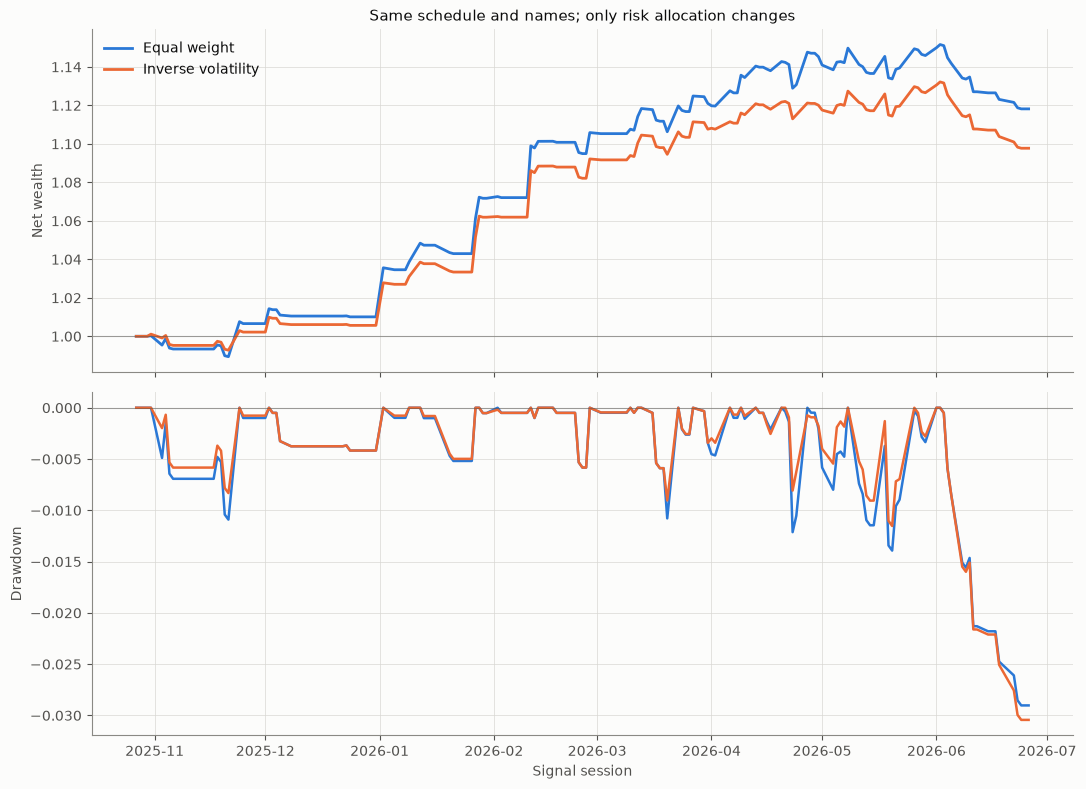

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for rule, daily, color in (
    ("Equal weight", equal_daily, CATEGORICAL[0]),
    ("Inverse volatility", risk_daily, CATEGORICAL[1]),
):
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    axes[0].plot(daily["session_date"], equity, label=rule, color=color, linewidth=2)
    axes[1].plot(daily["session_date"], drawdown, label=rule, color=color, linewidth=1.8)
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8, alpha=0.5)
axes[0].set_ylabel("Net wealth")
axes[0].set_title("Same schedule and names; only risk allocation changes")
axes[0].legend(frameon=False)
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Signal session")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=180, bbox_inches="tight")
plt.show()

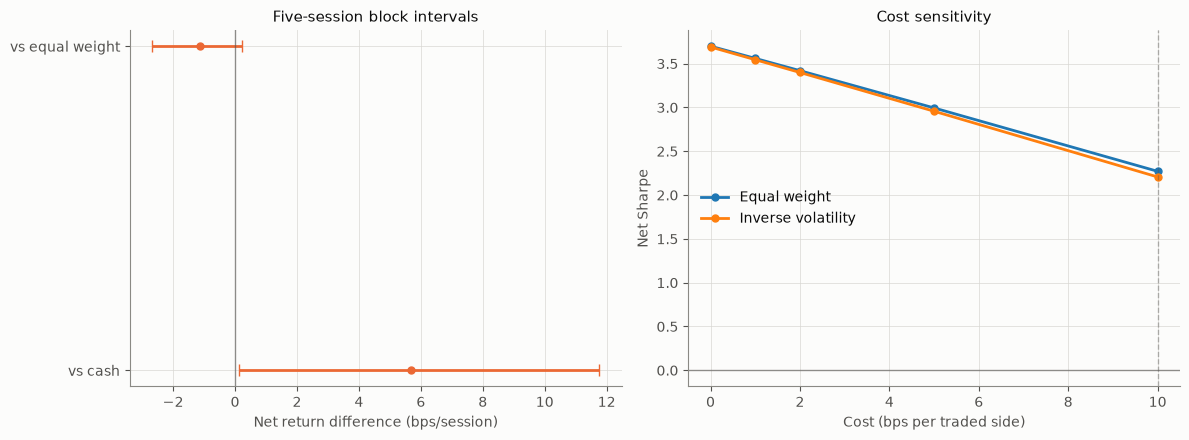

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_inference = paired_inference.copy()
labels = ["vs cash", "vs equal weight"]
means = plot_inference["mean_difference"].to_numpy() * 10_000.0
low = plot_inference["ci_low"].to_numpy() * 10_000.0
high = plot_inference["ci_high"].to_numpy() * 10_000.0
axes[0].errorbar(
    means,
    np.arange(len(labels)),
    xerr=np.vstack([means - low, high - means]),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=1, alpha=0.6)
axes[0].set_yticks(np.arange(len(labels)), labels)
axes[0].set_xlabel("Net return difference (bps/session)")
axes[0].set_title("Five-session block intervals")
for rule, group in cost_curve.groupby("rule"):
    label = "Equal weight" if rule == "equal_weight_hybrid" else "Inverse volatility"
    axes[1].plot(
        group["cost_bps_per_side"],
        group["sharpe_net"],
        marker="o",
        label=label,
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=1, alpha=0.6)
axes[1].axvline(COST_BPS, color=INK["reference"], linewidth=1, alpha=0.4, linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paired_effects_and_costs.png", dpi=180, bbox_inches="tight")
plt.show()

In [10]:
input_gate.to_csv(OUTPUT_DIR / "input_gate.csv", index=False)
target_audit.to_csv(OUTPUT_DIR / "target_audit.csv", index=False)
return_audit.to_csv(OUTPUT_DIR / "return_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
factor_panel.to_csv(OUTPUT_DIR / "factor_panel.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
equal_daily.to_parquet(OUTPUT_DIR / "equal_weight_daily.parquet", index=False)
risk_daily.to_parquet(OUTPUT_DIR / "inverse_volatility_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_FROZEN_HYBRID_INVERSE_VOLATILITY_AUDIT",
    "notebook": "50_lseg_gemma_hybrid_inverse_volatility.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "notebook36_manifest": str(NOTEBOOK36_MANIFEST.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
    },
    "specification": {
        "candidate": "Gemma exact-event schedule/counts plus FinBERT rank with inverse-volatility allocation",
        "universe": "immutable original 33",
        "volatility": {
            "input": "strictly lagged open-to-open return standard deviation",
            "lookback_sessions": VOLATILITY_LOOKBACK,
            "minimum_observations": VOLATILITY_MIN_OBSERVATIONS,
            "floor": constraints.volatility_floor,
        },
        "projector": "existing project_target_weights; gross 1, net 0, name cap 25%; unused capacity remains cash",
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "inference": f"two paired comparisons; {REPLICATIONS} five-session circular-block replications; BH-FDR q=0.05",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "leave_one_out": "rebuild Gemma schedule and FinBERT rank after every exclusion",
        "final_liquidation": True,
    },
    "input_gate": json.loads(input_gate.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal": json.loads(temporal.to_json(orient="records")),
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 36 and its opened outcomes directly motivated this risk-allocation audit",
        "the eight-month LSEG window is not an independent holdout",
        "the first observations use the frozen five-observation minimum rather than a complete 20-session window",
        "the volatility lookback and floor are inherited conventional settings, not selected here",
        "the factor model controls static contemporaneous exposures, not dynamic causal channels",
        "the original-33 equal-weight sector factors are internal portfolio benchmarks",
        "human validation of full-corpus Gemma labels remains open",
        "even a passing retrospective gate is not deployable alpha",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_FROZEN_HYBRID_INVERSE_VOLATILITY_AUDIT",
  "notebook": "50_lseg_gemma_hybrid_inverse_volatility.ipynb",
  "git_commit_at_execution": "76c77397af62bb1de842c5989c931c21e2bfd3d3",
  "seed": 20260812,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "notebook36_manifest": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "licensed_headline_text_loaded": false
  },
  "specification": {
    "candidate": "Gemma exact-event schedule/counts plus FinBERT rank with inverse-volatility allocation",
    "universe": "immutable original 33",
    "volatility": {
      "input": "strictly lagged open-to-open return standard deviation",
      "

## Interpretation

The displayed gates decide whether inverse-volatility allocation improves the frozen
hybrid, not whether the opened LSEG window contains validated alpha. The relevant
economic comparison is net of 10 bps per traded side and includes terminal liquidation.
Inverse-volatility sizing lowers annualised net volatility and turnover but also lowers
net return and does not improve the equal-weight hybrid significantly. Its gross/net
Sharpe remains strategy-shaped, yet neither the BH-adjusted cash comparison nor the
sector-spanning alpha gate passes. Preserve the risk/cost trade-off as a useful null;
the equal-weight hybrid remains the leading same-window candidate and still requires
genuinely new dates plus Gate F1 before any promotion.